In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv("customer_segmentation.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


Clean the data

In [9]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [10]:
print(df['Income'].isnull().sum())

0


In [11]:
income_limit = df['Income'].quantile(0.99)

df['Income_Clean'] = df['Income'].clip(upper=income_limit)

Create useful customer behaviour features

Total spending

In [12]:
spending_columns = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df['TotalSpend'] = df[spending_columns].sum(axis=1)

Total purchases

In [13]:
purchase_columns = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumDealsPurchases'
]

df['TotalPurchases'] = df[purchase_columns].sum(axis=1)

Total campaign responses

In [14]:
campaign_columns = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response'
]

df['TotalCampaignAccepted'] = df[campaign_columns].sum(axis=1)

Number of children

In [15]:
df['Children'] = df['Kidhome'] + df['Teenhome']

Age

In [16]:
df['Age'] = 2014 - df['Year_Birth']

Check our new features

In [17]:
df[
    [
        'Income_Clean',
        'Recency',
        'TotalSpend',
        'TotalPurchases',
        'TotalCampaignAccepted',
        'Children',
        'Age'
    ]
].describe()

,Income_Clean,Recency,TotalSpend,TotalPurchases,TotalCampaignAccepted,Children,Age
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,51751.681089,49.109375,605.798214,14.862054,0.446875,0.950446,45.194196
std,20648.623397,28.962453,602.249288,7.677173,0.890543,0.751803,11.984069
min,1730.000000,0.000000,5.000000,0.000000,0.000000,0.000000,18.000000
25%,35538.750000,24.000000,68.750000,8.000000,0.000000,0.000000,37.000000
50%,51381.500000,49.000000,396.000000,15.000000,0.000000,1.000000,44.000000
75%,68289.750000,74.000000,1045.500000,21.000000,1.000000,1.000000,55.000000
max,94437.680000,99.000000,2525.000000,44.000000,5.000000,3.000000,121.000000


Exploratory Data Analysis.
Spending distribution

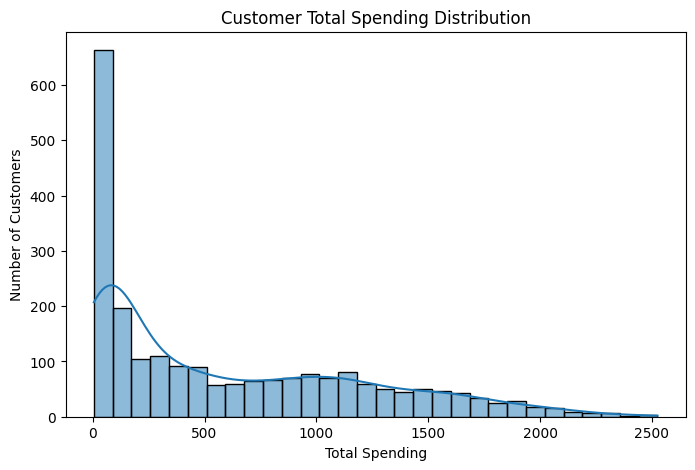

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalSpend'], bins=30, kde=True)

plt.title('Customer Total Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')

plt.show()

Purchase frequency

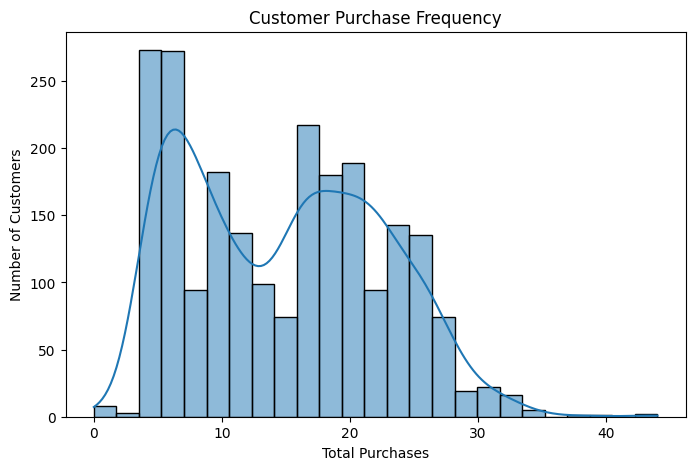

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalPurchases'], bins=25, kde=True)

plt.title('Customer Purchase Frequency')
plt.xlabel('Total Purchases')
plt.ylabel('Number of Customers')

plt.show()

Income vs spending

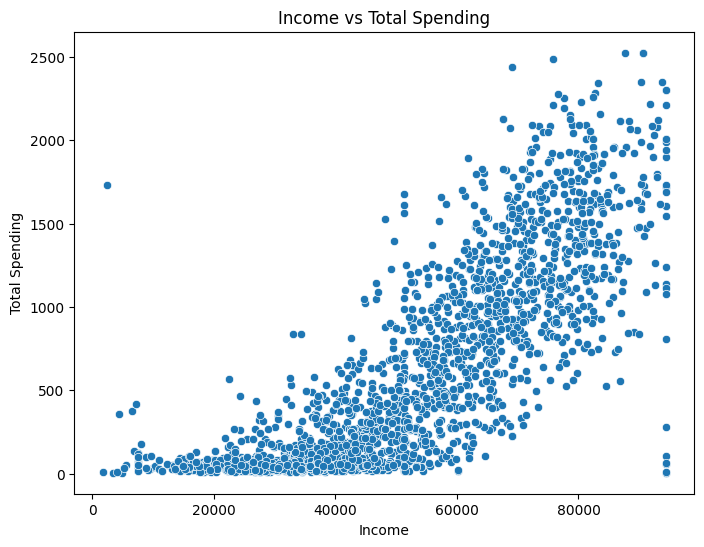

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Income_Clean',
    y='TotalSpend'
)

plt.title('Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')

plt.show()

Select features for segmentation.
For the actual clustering, we'll focus on customer behaviour, rather than throwing all 29 columns into K-Means.

In [22]:
features = [
    'Recency',
    'TotalPurchases',
    'TotalSpend'
]

Standardize the data

In [23]:
scaler = StandardScaler()

X = scaler.fit_transform(df[features])

In [24]:
inertia = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)

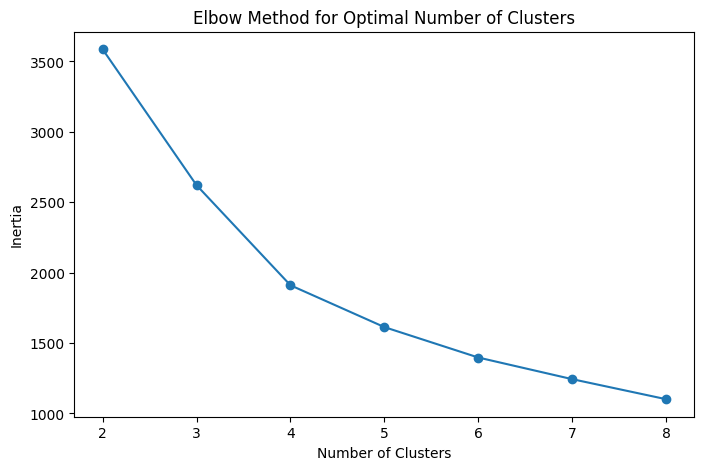

In [25]:
plt.figure(figsize=(8,5))

plt.plot(range(2,9), inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

Validate using Silhouette Score

In [26]:
for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    print(f"K = {k} | Silhouette Score = {score:.3f}")

K = 2 | Silhouette Score = 0.418
K = 3 | Silhouette Score = 0.377
K = 4 | Silhouette Score = 0.377
K = 5 | Silhouette Score = 0.369
K = 6 | Silhouette Score = 0.356
K = 7 | Silhouette Score = 0.333
K = 8 | Silhouette Score = 0.342


Create the customer segments

In [27]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

df['Cluster'] = kmeans.fit_predict(X)

In [28]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,497
1,582
2,613
3,548


Profile the segments

In [29]:
cluster_summary = df.groupby('Cluster').agg(
    Customers=('ID', 'count'),
    Avg_Income=('Income_Clean', 'mean'),
    Avg_Recency=('Recency', 'mean'),
    Avg_TotalSpend=('TotalSpend', 'mean'),
    Avg_TotalPurchases=('TotalPurchases', 'mean'),
    Avg_CampaignAccepted=('TotalCampaignAccepted', 'mean')
).round(2)

cluster_summary

,Customers,Avg_Income,Avg_Recency,Avg_TotalSpend,Avg_TotalPurchases,Avg_CampaignAccepted
Cluster,,,,,,
0,497,68742.14,23.08,1140.88,22.00,0.85
1,582,37282.96,74.74,137.32,8.93,0.12
2,613,37059.57,24.48,134.01,8.78,0.23
3,548,68143.66,73.05,1145.81,21.50,0.67


Visualize the segments.                         Spending vs purchasing frequency

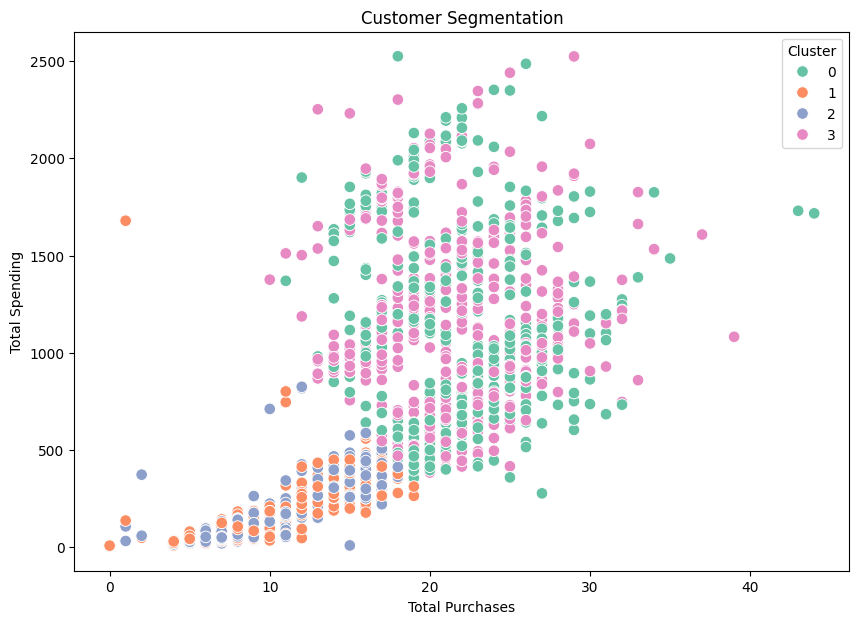

In [30]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='TotalPurchases',
    y='TotalSpend',
    hue='Cluster',
    palette='Set2',
    s=70
)

plt.title('Customer Segmentation')
plt.xlabel('Total Purchases')
plt.ylabel('Total Spending')

plt.show()

Customer segment distribution

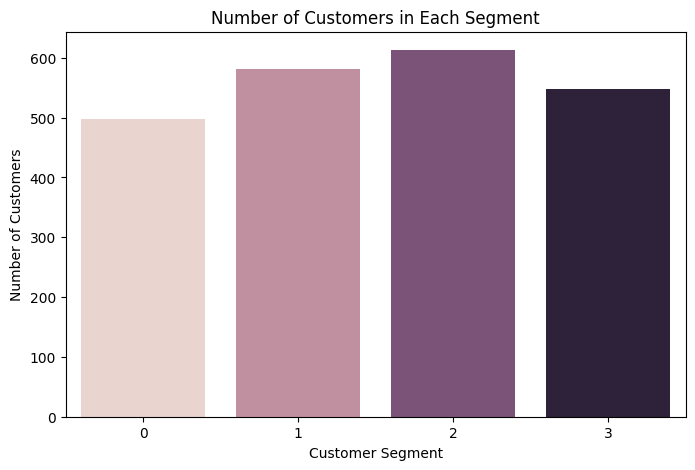

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Cluster',
    hue='Cluster',
    legend=False
)

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.show()

Analyze product preferences

In [32]:
product_columns = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

product_summary = df.groupby('Cluster')[product_columns].mean().round(2)

product_summary

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,573.62,50.31,325.79,69.36,50.23,71.56
1,61.79,6.77,33.92,9.26,6.66,18.90
2,63.50,6.41,28.94,9.97,5.80,19.38
3,585.47,47.51,318.54,69.49,51.50,73.29


Analyze purchasing channels

In [33]:
channel_columns = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

channel_summary = df.groupby('Cluster')[channel_columns].mean().round(2)

channel_summary

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Cluster,,,
0,6.12,4.81,8.49
1,2.46,0.75,3.53
2,2.43,0.70,3.54
3,5.82,4.93,8.25


Final insights

Segment 1: Customers in this segment show higher purchase frequency and spending compared with other segments.

Segment 2: Customers in this segment demonstrate lower purchasing activity and higher recency values.

Segment 3: Customers show stronger preference toward specific product categories.

Segment 4: Customers demonstrate a distinct purchasing-channel preference.

In [34]:
# Final Customer Segment Profile

final_profile = df.groupby('Cluster').agg(
    Customers=('ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Total_Purchases=('TotalPurchases', 'mean'),
    Avg_Total_Spend=('TotalSpend', 'mean'),
    Avg_Income=('Income_Clean', 'mean'),
    Avg_Web_Purchases=('NumWebPurchases', 'mean'),
    Avg_Catalog_Purchases=('NumCatalogPurchases', 'mean'),
    Avg_Store_Purchases=('NumStorePurchases', 'mean')
).round(2)

final_profile

,Customers,Avg_Recency,Avg_Total_Purchases,Avg_Total_Spend,Avg_Income,Avg_Web_Purchases,Avg_Catalog_Purchases,Avg_Store_Purchases
Cluster,,,,,,,,
0,497,23.08,22.00,1140.88,68742.14,6.12,4.81,8.49
1,582,74.74,8.93,137.32,37282.96,2.46,0.75,3.53
2,613,24.48,8.78,134.01,37059.57,2.43,0.70,3.54
3,548,73.05,21.50,1145.81,68143.66,5.82,4.93,8.25


In [35]:
# Product preferences by customer segment

product_profile = df.groupby('Cluster')[
    [
        'MntWines',
        'MntFruits',
        'MntMeatProducts',
        'MntFishProducts',
        'MntSweetProducts',
        'MntGoldProds'
    ]
].mean().round(2)

product_profile

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,573.62,50.31,325.79,69.36,50.23,71.56
1,61.79,6.77,33.92,9.26,6.66,18.90
2,63.50,6.41,28.94,9.97,5.80,19.38
3,585.47,47.51,318.54,69.49,51.50,73.29


In [36]:
# Customer segment sizes

segment_size = df['Cluster'].value_counts().sort_index()

print("Customers in each segment:")
print(segment_size)

Customers in each segment:
Cluster
0    497
1    582
2    613
3    548
Name: count, dtype: int64


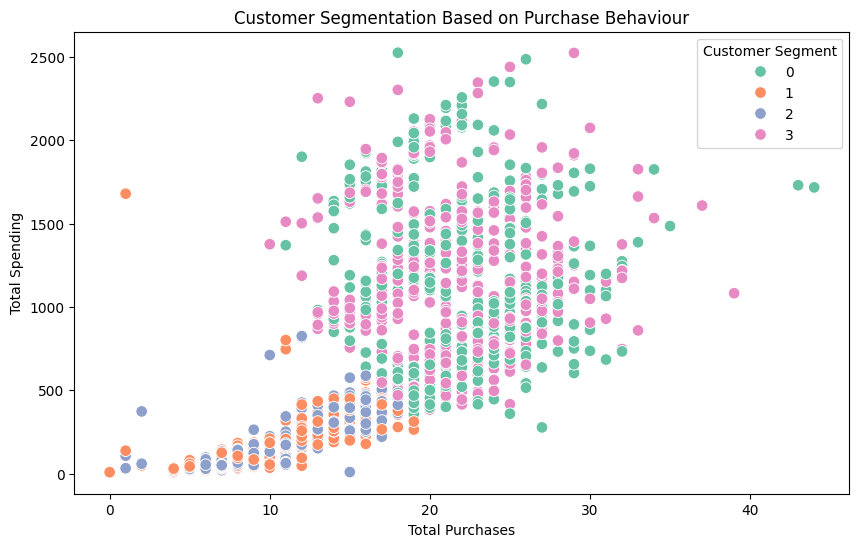

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='TotalPurchases',
    y='TotalSpend',
    hue='Cluster',
    palette='Set2',
    s=70
)

plt.title('Customer Segmentation Based on Purchase Behaviour')
plt.xlabel('Total Purchases')
plt.ylabel('Total Spending')
plt.legend(title='Customer Segment')
plt.show()

## Conclusion

## Project Objective

The objective of this project is to segment customers according to their demographic and purchasing behaviour using machine learning techniques. K-Means clustering is used to identify groups of customers with similar characteristics, enabling better understanding of customer preferences and purchasing patterns.